In [ ]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [3]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec

In [ ]:
# load data for regions plot
from GridMaze.analysis.anatomy import regions

region_counts_df = regions.get_subject_cell_counts(ignore_layers=True)

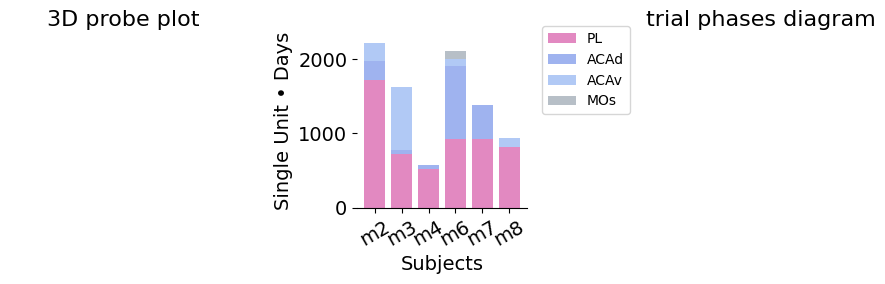

In [ ]:
# we recorded cells
fig1, axes = plt.subplots(1, 3, figsize=(9, 3), clear=True, width_ratios=[1, 0.75, 1])
axes[0].set_title("3D probe plot")
axes[0].axis("off")
axes[2].set_title("trial phases diagram")
axes[2].axis("off")
regions.plot_subject_cell_counts(region_counts_df, ax=axes[1])
fig1.tight_layout()
fig1.savefig("../results/anatomy/regions.pdf")

In [5]:
# load data for population activity plot
from GridMaze.analysis.event_aligned import population_activity as pa

reload(pa)

aligned_activity_df = pa.get_aligned_population_activity(aligned_to="trial")

frames.navigation.parquet not found for m8.2022-07-26.maze


In [6]:
# lfp figure
from GridMaze.analysis.event_aligned import lfp

signal_type = "LFP"  # LFP or CSD

spectrogram_df = lfp.load_spectrogram_df(signal_type)
PSD_df = lfp.load_PSD_df(signal_type)
signal_df = lfp.load_signal_df(signal_type)

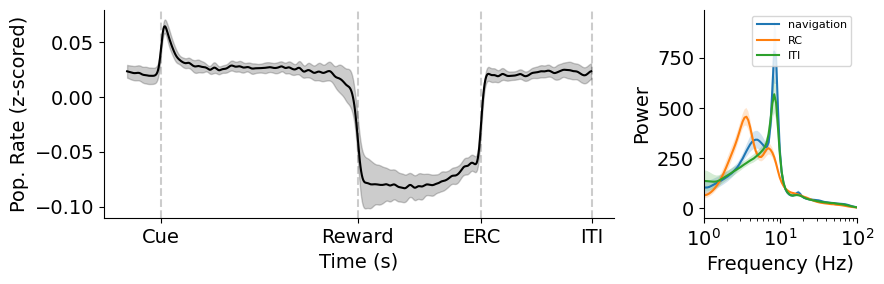

In [7]:
reload(pa)
# where single unit population activty was locked to trial events
fig2, axes = plt.subplots(1, 2, figsize=(9, 3), clear=True, width_ratios=[1, 0.3])
pa._plot_population_aligned_activity(aligned_activity_df, ax=axes[0])
lfp.plot_PSD(PSD_df, normalise=False, fmax=100, ax=axes[1])
fig2.tight_layout()
fig2.savefig("../results/event_aligned/population_activity.pdf")

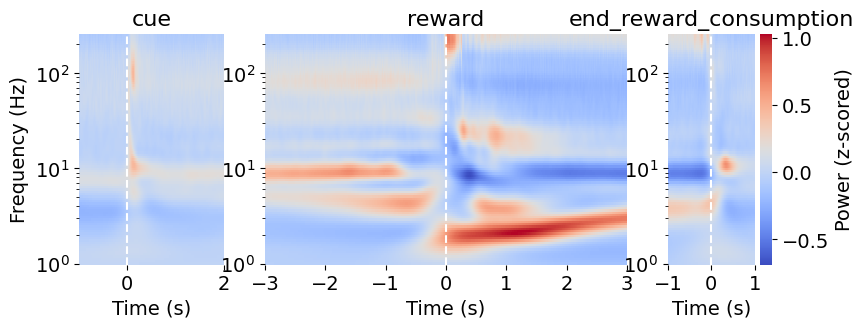

In [8]:
reload(lfp)
fig3, axes = plt.subplots(1, 3, figsize=(9, 3), width_ratios=[0.4, 1, 0.3], clear=True)
lfp.plot_average_spectrogram(spectrogram_df, axes=axes)
fig3.savefig("../results/event_aligned/LFP_1.pdf")

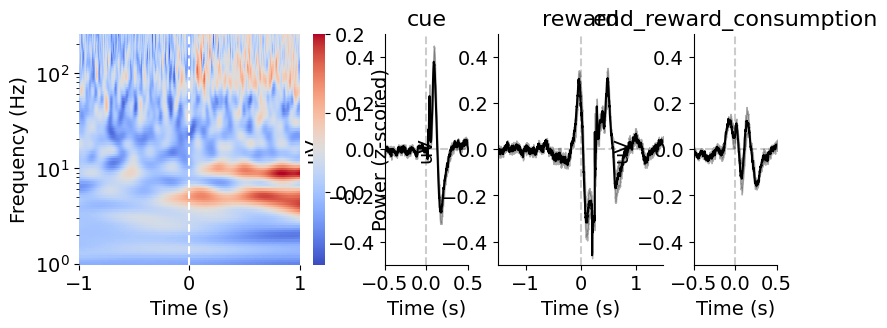

In [ ]:
reload(lfp)
fig4, axes = plt.subplots(1, 3, figsize=(9, 3), width_ratios=[0.4, 1, 0.4], clear=True)
lfp.plot_av_event_aligned_signal(
    signal_df, axes=axes, windows={"cue": (-0.5, 0.5), "reward": (-1.5, 1.5), "end_reward_consumption": (-0.5, 0.5)}
)
fig4.savefig("../results/event_aligned/LFP_2.pdf")

In [10]:
from GridMaze.analysis.event_aligned import cluster_heatmaps as ch

sessions = ch.get_sessions_for_analysis()
heatmap_df = ch.get_trial_aligned_activity_heatmap(
    sessions, smooth_SD=10, normalisation="zscore", cluster_method="KMeans", n_clusters=6, plot=False
)

In [ ]:
# heatmap
reload(ch)
fig5, ax = plt.subplots(1, 1, figsize=(6, 4.5), clear=True)
ch.plot_trial_aligned_heatmap(heatmap_df.firing_rate, normalisation_method="zscore", ax=ax)
fig5.tight_layout()
fig5.savefig("../results/event_aligned/cluster_heatmap.pdf")

In [53]:
from GridMaze.analysis.core import get_clusters as gc

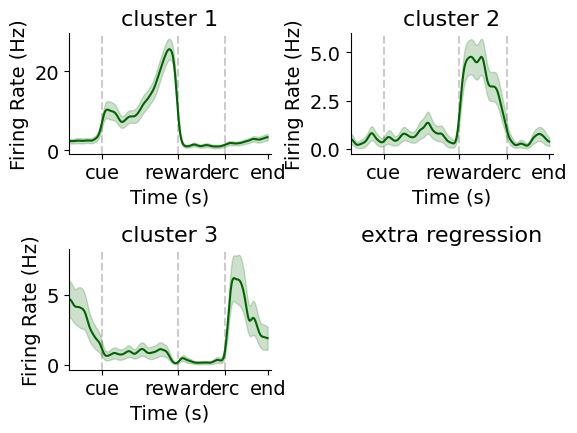

In [71]:
# plot some example cells
cluster_1 = gc.get_cluster("m2.2022-07-03.maze_cluster9")  # Nav tuned
cluster_2 = gc.get_cluster("m2.2022-06-30.maze_cluster34")  # RC tuned
cluster_3 = gc.get_cluster("m2.2022-07-12.maze_cluster54")  # ITI tuned

fig6, axes = plt.subplots(2, 2, figsize=(6, 4.5), clear=True)
axes[0, 0].set_title("cluster 1")
cluster_1.plot_tuning(feature="trial_events", ax=axes[0, 0])
axes[0, 1].set_title("cluster 2")
cluster_2.plot_tuning(feature="trial_events", ax=axes[0, 1])
axes[1, 0].set_title("cluster 3")
cluster_3.plot_tuning(feature="trial_events", ax=axes[1, 0])
axes[1, 1].axis("off")
axes[1, 1].set_title("extra regression")
fig6.tight_layout()
fig6.savefig("../results/event_aligned/example_cells.pdf")